# Job Shop Scheduling

https://arxiv.org/pdf/2401.16381 and https://developers.google.com/optimization/scheduling/job_shop

We have a set of tasks $T$. Each task $t$ has a machine $m$, a duration $d$, and a set of parent tasks which must be completed before that task can be begun, $P$. Our goal is to minimise the makespan: the time at which the last task finishes.

This notebook demonstrates setting up the problem, solving it with various solvers, and benchmarking.

Classic job shop scheduling is where each job is a chain of tasks; here we have arbitrary precedence, i.e. any task can take any task as a precedent, as long as there are no cycles. This is more general. It also means we can use standard benchmark instances like OR-Library's `ft06`, `la01`-`la40`, Taillard's.

## Constraints

- one start time per task (one-hot; for QAOA a weight-preserving mixer *per task* enforces this)
- every parent finishes before its child starts
- one task per machine at a given time (automatic)

## Notes

There are a few optimisations we can make:

- **start-time windows**
    - task $i$ cannot start before the preceding tasks have finished, and cannot start so late that following work does not fit
    - therefore at both ends, we take the better bound of the critical path, and the busiest machine's total load
    - $\text{earliest}(i) = \max\left(\text{longest chain into } i,\; \max_m \sum_{p\,\in\,A(i),\; m_p = m} d_p\right)$
    - $\text{latest}(i) = \text{horizon} - \max\left(\text{longest chain out of } i,\; \max_m \sum_{c\,\in\,C(i)\,\cup\,\{i\},\; m_c = m} d_c\right)$
    - this is useful for reducing the problem size
- **horizon**
    - we want to start off with a tight horizon to also reduce the problem size
    - therefore we greedily solve the problem - the makespan of this solution is taken as the horizon
    - in fact, our solution will be optimal if the critical path dominates the constraints
- **makespan task**
    - our naive objective would be a $\max$ function, which can't be a QUBO
    - therefore, we add a dummy makespan task which depends on every childless task and has zero duration
    - then, the start time of this task is the solution's makespan, and we can just minimise this!
- **penalties**
    - since the maximum feasible objective value is the horizon, all infeasible solutions need to have an energy above that

## Benchmarking

When we come to benchmarking, we shoyld use the following metrics:

- TTS R99 (`t_run * ln(0.01) / ln(1 - p)`), the expected time to see an optimal solution at least once with 99% confidence, where `p` is the fraction of runs which hit the optimum
- TTS 1, the plain wall-clock time till the first optimal solution

## Problem Setup

A task is `(machine, duration, dependencies)`.

In [1]:
from problem import Problem
from formulation import build_formulation
from draw import draw
from classical import GreedySolver, ExactSolver, GurobiSolver
from variational import QAOASolver, LRQAOASolver, VQESolver
from backends import aer_backend, ibm_backend
from annealing import SimulatedAnnealingSolver, QuantumAnnealingSolver

7 tasks on 3 machines
Makespan can range from 10 to 10
20 qubits, 68 QUBO terms, 48 couplings


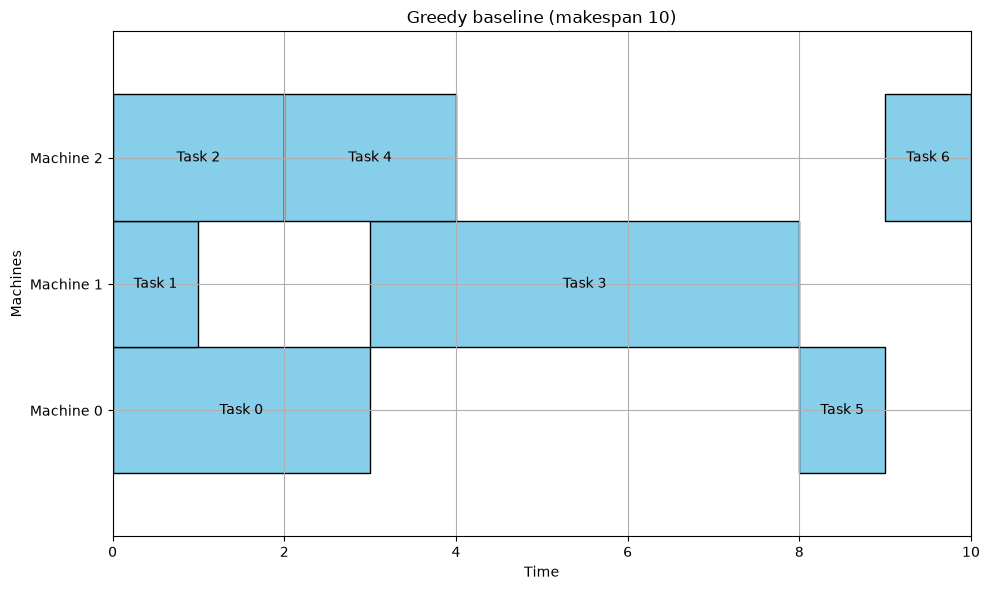

In [2]:
# example set of tasks
tasks = [
    (0,3,()),
    (1,1,()),
    (2,2,()),
    (1,5,(0,1)),
    (2,2,(2,)),
    (0,1,(3,)),
    (2,1,(3,4,5))
]

problem = Problem(tasks)
formulation = build_formulation(problem)

# let's explore this instance
print(f"{len(problem)} tasks on {problem.num_machines} machines")
print(f"Makespan can range from {problem.lower_bound} to {problem.horizon}")
print(f"{formulation.num_variables} qubits, {len(formulation.Q)} QUBO terms,"
      f" {formulation.num_couplings} couplings")

# we can illustrate with 
draw(problem, problem.greedy(), "Greedy baseline")

## Classical solvers

In [3]:
# first we do the greedy solution
GreedySolver().solve(problem).pprint()

greedy result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 0, 0, 3, 2, 8, 9]
 * time taken   : 0.00016870000399649143
 * calls        : 1
 * metadata     : {
    "calls_unit": "passes"
}


In [4]:
# then the exact solution
ExactSolver().solve(problem).pprint()

exact result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 0, 0, 3, 2, 8, 9]
 * time taken   : 0.001981699955649674
 * calls        : 108
 * metadata     : {
    "calls_unit": "candidates",
    "combinations": 108,
    "variables": 19,
    "couplings": 0
}


In [5]:
# then the gurobi solver
GurobiSolver(model="qubo").solve(problem).pprint()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 235U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 0 rows, 20 columns and 0 nonzeros (Min)
Model fingerprint: 0x88dd6930
Model has 0 linear objective coefficients and an objective constant of 88
Model has 68 quadratic objective terms
Variable types: 0 continuous, 20 integer (20 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 4e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]

Found heuristic solution: objective 88.0000000
Found heuristic solution: objective 10.0000000
Presolve removed 0 rows and 8 columns
Presolve time: 0.01s
Presolved: 45 rows, 57 columns, 135 nonzeros
Variable types: 0 continuous, 57 integer

## Variational Solvers

In [6]:
QAOASolver(backend=aer_backend(), reps=2).solve(problem).pprint()

qaoa/aer result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 1, 3, 3, 7, 8, 9]
 * time taken   : 8.772310400032438
 * calls        : 44
 * metadata     : {
    "calls_unit": "circuit executions",
    "reps": 2,
    "shots": 4096,
    "alpha": 1.0,
    "backend": "aer",
    "final_objective": 12.4814453125
}


In [8]:
LRQAOASolver(backend=aer_backend(), p=20, delta_gamma=0.5, delta_beta=0.3).solve(problem).pprint()

lr-qaoa/aer result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 2, 3, 3, 7, 8, 9]
 * time taken   : 0.7789110000012442
 * calls        : 1
 * metadata     : {
    "calls_unit": "circuit executions",
    "p": 20,
    "shots": 4096,
    "delta_gamma": 0.5,
    "delta_beta": 0.3,
    "backend": "aer",
    "depth": 389,
    "parameter_free": true
}


In [9]:
VQESolver(backend=aer_backend(), p=2).solve(problem).pprint()

vqe/aer result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 0, 5, 3, 7, 8, 9]
 * time taken   : 69.90873530000681
 * calls        : 300
 * metadata     : {
    "calls_unit": "circuit executions",
    "p": 3,
    "shots": 4096,
    "alpha": 0.25,
    "backend": "aer",
    "parameters": 80,
    "final_objective": 10.0
}


## Annealing Solvers

In [11]:
SimulatedAnnealingSolver().solve(problem).pprint()

simulated-annealing result
 * feasible     : True
 * makespan     : 10
 * start times  : [0, 1, 2, 3, 6, 8, 9]
 * time taken   : 0.24185699998633936
 * calls        : 1000
 * metadata     : {
    "calls_unit": "reads",
    "num_reads": 1000
}
